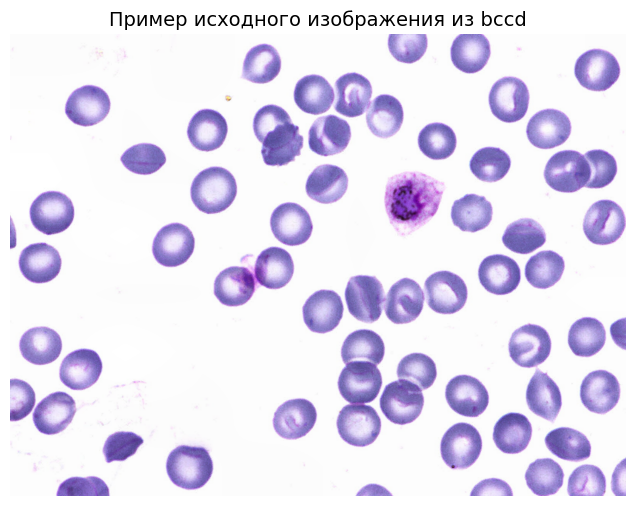

In [1]:
import cv2, os, matplotlib.pyplot as plt

img_path = os.path.join(r"bccd/train/images", os.listdir(r"bccd/train/images")[0])
img = cv2.imread(img_path)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Пример исходного изображения из bccd", fontsize=14)
plt.axis('off')
plt.show()

In [2]:
# настройка окружения
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from typing import Tuple, List
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 8

### Нарезка патчей

In [ ]:
def load_bccd_patches_to_ram(bccd_img_dir: str, bccd_mask_dir: str, patch_size=64):
    bg_patches, cell_patches = [], []
    
    if not os.path.exists(bccd_img_dir) or not os.path.exists(bccd_mask_dir):
        print(f"[WARN] Папки не найдены. Будет использована только синтетика.")
        return bg_patches, cell_patches

    print("Быстрая нарезка датасета...")
    mask_files = os.listdir(bccd_mask_dir)
    mask_dict = {os.path.splitext(f)[0]: f for f in mask_files}
    
    for img_name in os.listdir(bccd_img_dir):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img = cv2.imread(os.path.join(bccd_img_dir, img_name))
        if img is None: continue
        
        base_name = os.path.splitext(img_name)[0]
        if base_name not in mask_dict: continue
            
        mask = cv2.imread(os.path.join(bccd_mask_dir, mask_dict[base_name]), cv2.IMREAD_GRAYSCALE)
        if mask is None: continue
        
        _, mask_bin = cv2.threshold(mask, 10, 255, cv2.THRESH_BINARY)
        h, w = img.shape[:2]
        step = patch_size // 2 
        
        for y in range(0, h - patch_size + 1, step):
            for x in range(0, w - patch_size + 1, step):
                p_mask = mask_bin[y:y+patch_size, x:x+patch_size]
                p_img = img[y:y+patch_size, x:x+patch_size]
                
                cell_pixels = np.sum(p_mask > 0)
                total_pixels = patch_size * patch_size
                
                if cell_pixels > total_pixels * 0.5:
                    cell_patches.append(p_img.copy())
                elif cell_pixels == 0:
                    bg_patches.append(p_img.copy())
                    
    print(f"Загружено: {len(bg_patches)} фонов, {len(cell_patches)} клеток.")
    return bg_patches, cell_patches


### Генератор (по шаблону PYTORCH DATASET)

In [ ]:
class BloodCellDataset(Dataset):
    def __init__(self, img_size: Tuple[int, int], dataset_size: int, 
                 bg_patches: List[np.ndarray], cell_patches: List[np.ndarray], 
                 noise_type: str = 'gaussian', use_synthetic: bool = True):
        super().__init__()
        self.image_size = img_size
        self.dataset_size = dataset_size
        self.noise_type = noise_type
        self.use_synthetic = use_synthetic
        self.bg_patches = bg_patches
        self.cell_patches = cell_patches
        self.bg_colors = [(220, 200, 200), (240, 220, 210), (210, 190, 195)]
        self.cell_colors = [(80, 60, 120), (160, 80, 100), (100, 100, 160)]

    def __len__(self) -> int: return self.dataset_size

    def __getitem__(self, idx: int) -> Tuple[np.ndarray, np.ndarray, int]:
        h, w = self.image_size
        
        if random.random() < 0.5 and len(self.bg_patches) > 0:
            patch = random.choice(self.bg_patches)
            bg = cv2.resize(patch, (w, h))
        elif self.use_synthetic:
            bg = np.full((h, w, 3), random.choice(self.bg_colors), dtype=np.uint8)
        else:
            bg = np.zeros((h, w, 3), dtype=np.uint8)
        bg = cv2.GaussianBlur(bg, (3, 3), 0)
        
        count = random.randint(3, 10)
        for _ in range(count):
            cell_size = random.randint(16, 40)
            margin = cell_size // 2 + 10 
            x = random.randint(margin, w - margin - cell_size)
            y = random.randint(margin, h - margin - cell_size)
            cell, mask = self._get_cell(cell_size)
            if cell is None: continue
            center = (x + cell_size // 2, y + cell_size // 2)
            try:
                bg = cv2.seamlessClone(cell, bg, mask, center, cv2.NORMAL_CLONE)
            except Exception: pass 

        clean_img = bg
        noisy_img = self._add_noise(clean_img)
        return clean_img, noisy_img, count

    def _get_cell(self, size):
        if random.random() < 0.5 and len(self.cell_patches) > 0:
            cell = random.choice(self.cell_patches)
            cell = cv2.resize(cell, (size, size))
            mask = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)
            _, mask = cv2.threshold(mask, 10, 255, cv2.THRESH_BINARY)
        elif self.use_synthetic:
            cell = np.zeros((size, size, 3), dtype=np.uint8)
            cv2.circle(cell, (size//2, size//2), size//2 - 2, random.choice(self.cell_colors), -1)
            mask = np.zeros((size, size), dtype=np.uint8)
            cv2.circle(mask, (size//2, size//2), size//2 - 2, 255, -1)
        else: return None, None
        return cell, mask

    def _add_noise(self, img):
        noisy = img.copy().astype(np.float32)
        row, col, ch = img.shape
        if self.noise_type == 'gaussian':
            noise = np.random.normal(0, 20, (row, col, ch))
        elif self.noise_type == 'uniform':
            noise = np.random.uniform(-50, 50, (row, col, ch))
        else: return img
        return np.clip(noisy + noise, 0, 255).astype(np.uint8)

# Вспомогательная функция для конвертации BGR (OpenCV) в RGB (Matplotlib)
def bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

### Визуализации

In [ ]:
def visualize_patches(bg_patches, cell_patches, num_to_show=8):
    """Показывает сетку нарезанных патчей"""
    fig, axes = plt.subplots(2, num_to_show, figsize=(16, 4))
    fig.suptitle("Этап 1: Нарезка исходного датасета на патчи", fontsize=14, fontweight='bold')
    
    for i in range(num_to_show):
        axes[0, i].imshow(bgr_to_rgb(bg_patches[i]) if i < len(bg_patches) else np.zeros((64,64,3), dtype=np.uint8))
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title("Патчи фона", color='blue', fontsize=12)
        
        axes[1, i].imshow(bgr_to_rgb(cell_patches[i]) if i < len(cell_patches) else np.zeros((64,64,3), dtype=np.uint8))
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title("Патчи клеток", color='red', fontsize=12)
    
    plt.tight_layout()
    plt.show()

def visualize_pipeline(dataset, filters_dict, noise_name):
    """Показывает процесс: оригинал -> шум -> восстановление (с метриками)"""
    clean_img, noisy_img, count = dataset[0]
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle(f"Этап 2: пайплайн генерации и пост-процессинг (шум: {noise_name.upper()})\n"
                 f"Сгенерировано клеток: {count}", fontsize=14, fontweight='bold')
    axes = axes.flatten()

    axes[0].imshow(bgr_to_rgb(clean_img))
    axes[0].set_title("Эталонное изображение", color='green', fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(bgr_to_rgb(noisy_img))
    axes[1].set_title(f"Зашумленное изображение\n({noise_name})", color='red', fontsize=10)
    axes[1].axis('off')

    # фильтры
    for idx, (f_name, f_func) in enumerate(filters_dict.items()):
        denoised = f_func(noisy_img)
        
        # метрики именно для этой картинки
        s = ssim(clean_img, denoised, channel_axis=-1, data_range=255)
        m = mean_squared_error(clean_img, denoised)
        
        axes[idx + 2].imshow(bgr_to_rgb(denoised))
        axes[idx + 2].set_title(f"{f_name}\nSSIM: {s:.3f} | MSE: {m:.1f}", fontsize=9)
        axes[idx + 2].axis('off')

    # прячем пустую 12-ю ячейку
    axes[11].axis('off')

    plt.tight_layout()
    plt.show()

### Бенчмарки

In [6]:
def run_benchmark(bg_patches, cell_patches):
    IMG_SIZE = (128, 128) 
    NUM_IMAGES = 50 # 100
    
    filters = {
        'Median (3x3)': lambda img: cv2.medianBlur(img, 3),
        'Median (5x5)': lambda img: cv2.medianBlur(img, 5),
        'Gaussian (3x3)': lambda img: cv2.GaussianBlur(img, (3, 3), 0),
        'Gaussian (5x5)': lambda img: cv2.GaussianBlur(img, (5, 5), 0),
        'Bilateral (d=9)': lambda img: cv2.bilateralFilter(img, 9, 75, 75),
        'Bilateral (d=15)': lambda img: cv2.bilateralFilter(img, 15, 100, 100),
        'NLM (h=10)': lambda img: cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21),
        'NLM (h=20)': lambda img: cv2.fastNlMeansDenoisingColored(img, None, 20, 20, 7, 21),
        'NLM (h=30)': lambda img: cv2.fastNlMeansDenoisingColored(img, None, 30, 30, 7, 21),
    }

    results = {nt: {fn: {'ssim': [], 'mse': []} for fn in filters} for nt in ['gaussian', 'uniform']}

    for noise_type in ['gaussian', 'uniform']:
        print(f"\n[ОЦЕНКА] Генерация и фильтрация {NUM_IMAGES} изображений (шум: {noise_type})...")
        dataset = BloodCellDataset(
            img_size=IMG_SIZE, dataset_size=NUM_IMAGES,
            bg_patches=bg_patches, cell_patches=cell_patches,
            noise_type=noise_type, use_synthetic=True
        )

        for i in range(len(dataset)):
            clean_img, noisy_img, _ = dataset[i] 
            for f_name, f_func in filters.items():
                denoised_img = f_func(noisy_img)
                results[noise_type][f_name]['ssim'].append(ssim(clean_img, denoised_img, channel_axis=-1, data_range=255))
                results[noise_type][f_name]['mse'].append(mean_squared_error(clean_img, denoised_img))

    for noise_type in results:
        print(f"\n{'='*65}")
        print(f"РЕЗУЛЬТАТЫ ДЛЯ ШУМА: {noise_type.upper()}")
        print(f"{'='*65}")
        print(f"{'Фильтр':<20} | {'Средний SSIM':<15} | {'Средний MSE':<15}")
        print("-" * 65)
        
        best_ssim_n, best_ssim_v = "", -1.0
        best_mse_n, best_mse_v = "", float('inf')
        
        for f_name, metrics in results[noise_type].items():
            avg_s = np.mean(metrics['ssim'])
            avg_m = np.mean(metrics['mse'])
            print(f"{f_name:<20} | {avg_s:<15.4f} | {avg_m:<15.2f}")
            if avg_s > best_ssim_v: best_ssim_v, best_ssim_n = avg_s, f_name
            if avg_m < best_mse_v: best_mse_v, best_mse_n = avg_m, f_name
            
        print("-" * 65)
        print(f"НАИЛУЧШИЙ ПО SSIM (структура): {best_ssim_n} ({best_ssim_v:.4f})")
        print(f"НАИЛУЧШИЙ ПО MSE  (ошибка):    {best_mse_n} ({best_mse_v:.2f})")
    
    return filters # словарь фильтров для передачи в визуализацию



In [7]:
# Загрузка
bg_patches_list, cell_patches_list = load_bccd_patches_to_ram(
    bccd_img_dir=r"bccd/train/images", 
    bccd_mask_dir=r"bccd/train/masks"
)

Быстрая нарезка датасета...
Загружено: 794246 фонов, 621732 клеток.


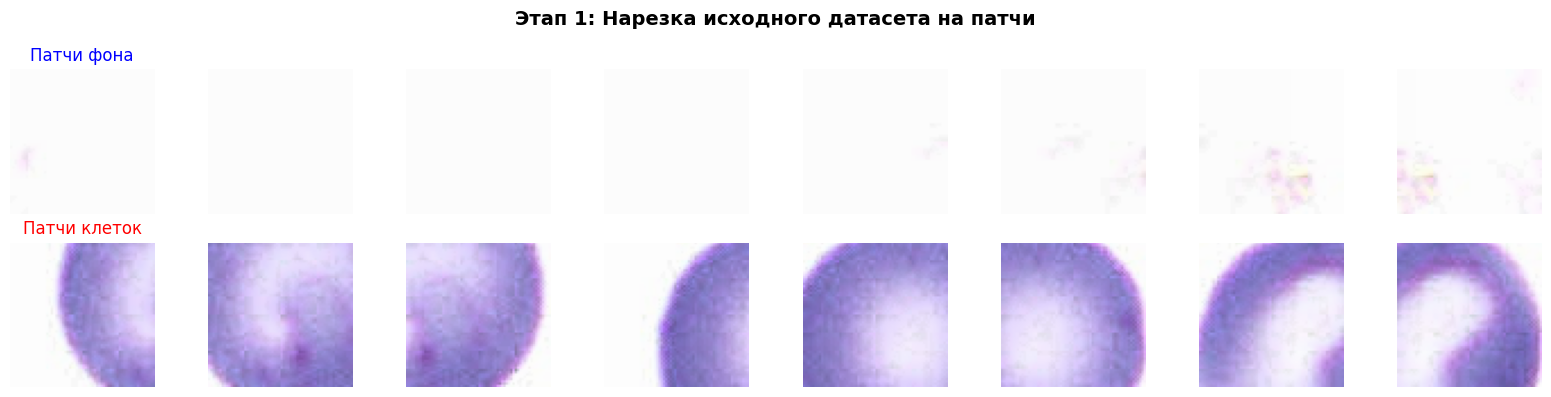

In [8]:
# Визуализация нарезки 
if len(bg_patches_list) > 0 and len(cell_patches_list) > 0:
    visualize_patches(bg_patches_list, cell_patches_list, num_to_show=8)
else:
    print("[СКИП] Визуализация нарезки пропущена (папки не найдены, используем синтетику).")

In [9]:
# Запуск бенчмарка
filters_dict = run_benchmark(bg_patches_list, cell_patches_list)


[ОЦЕНКА] Генерация и фильтрация 50 изображений (шум: gaussian)...

[ОЦЕНКА] Генерация и фильтрация 50 изображений (шум: uniform)...

РЕЗУЛЬТАТЫ ДЛЯ ШУМА: GAUSSIAN
Фильтр               | Средний SSIM    | Средний MSE    
-----------------------------------------------------------------
Median (3x3)         | 0.5576          | 66.67          
Median (5x5)         | 0.7834          | 28.46          
Gaussian (3x3)       | 0.6116          | 57.20          
Gaussian (5x5)       | 0.7558          | 35.01          
Bilateral (d=9)      | 0.8400          | 23.90          
Bilateral (d=15)     | 0.9231          | 18.36          
NLM (h=10)           | 0.9404          | 19.33          
NLM (h=20)           | 0.9326          | 25.93          
NLM (h=30)           | 0.9269          | 30.41          
-----------------------------------------------------------------
НАИЛУЧШИЙ ПО SSIM (структура): NLM (h=10) (0.9404)
НАИЛУЧШИЙ ПО MSE  (ошибка):    Bilateral (d=15) (18.36)

РЕЗУЛЬТАТЫ ДЛЯ ШУМА: UNIFO

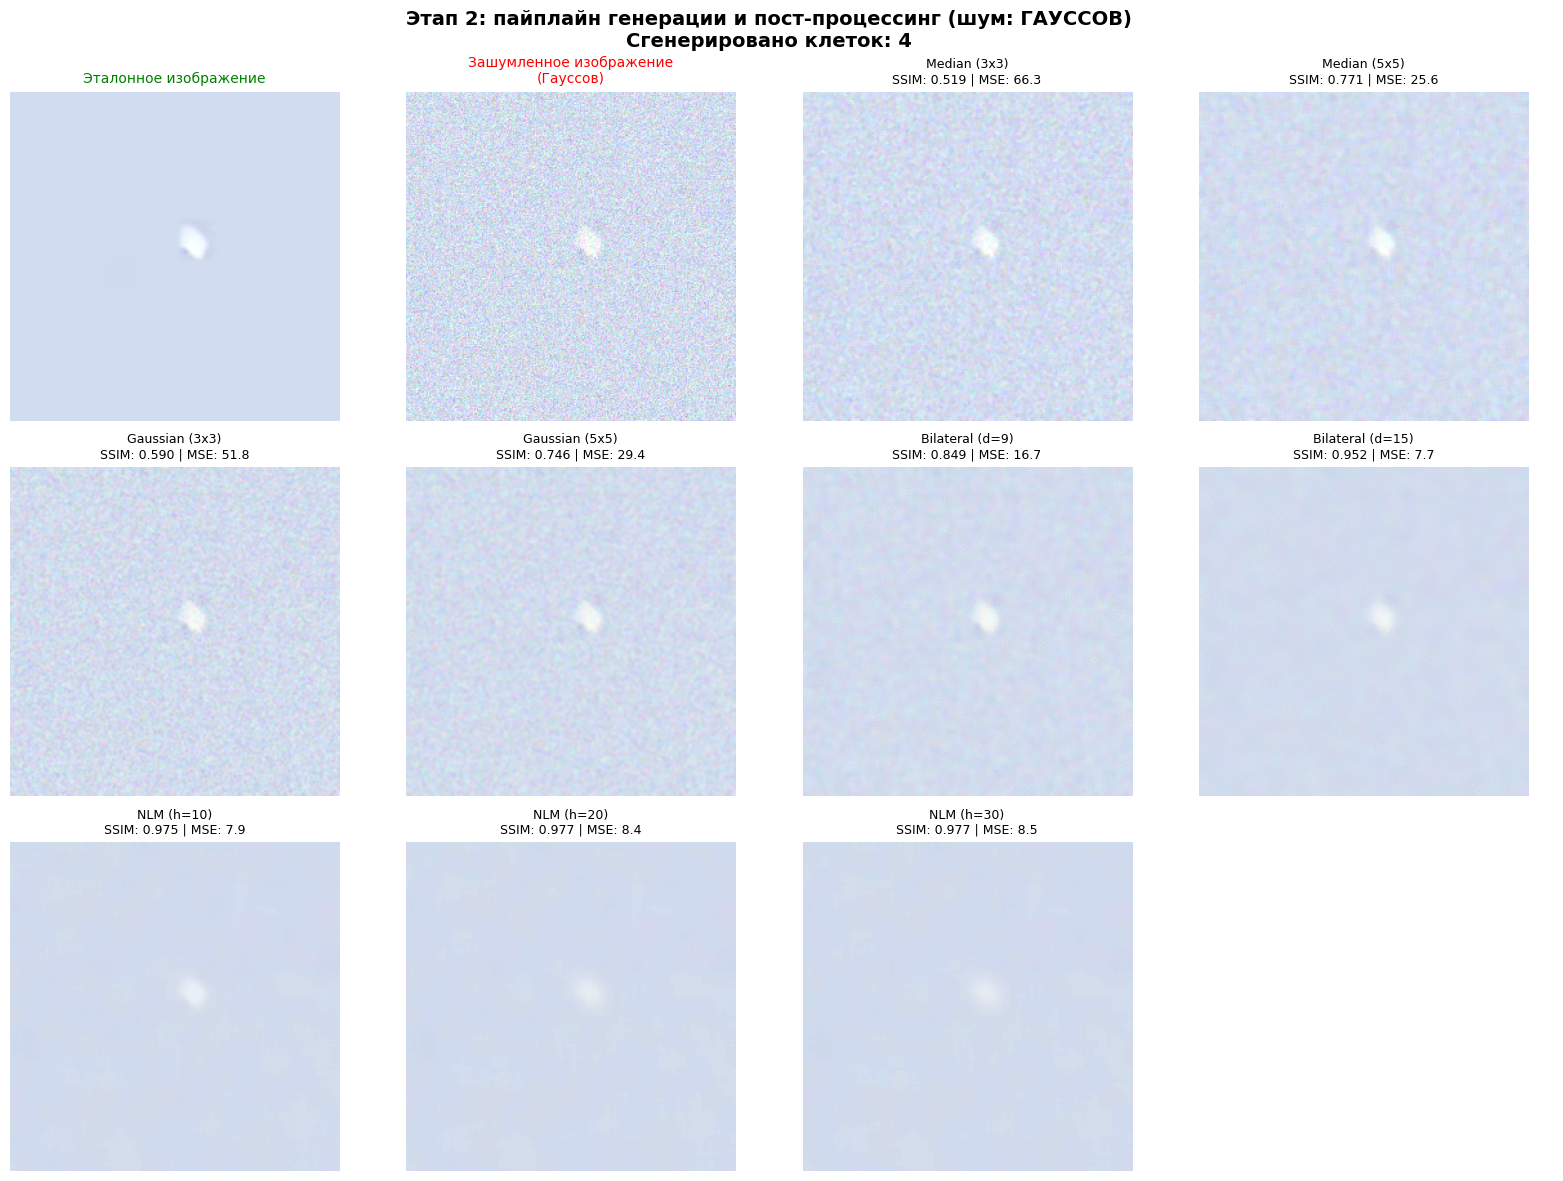

In [10]:
# Визуализация пайплайна пост-процессинга
# Пример для Гауссовского шума
ds_gauss = BloodCellDataset(
    img_size=(256, 256), dataset_size=1, 
    bg_patches=bg_patches_list, cell_patches=cell_patches_list,
    noise_type='gaussian', use_synthetic=True
)
visualize_pipeline(ds_gauss, filters_dict, "Гауссов")

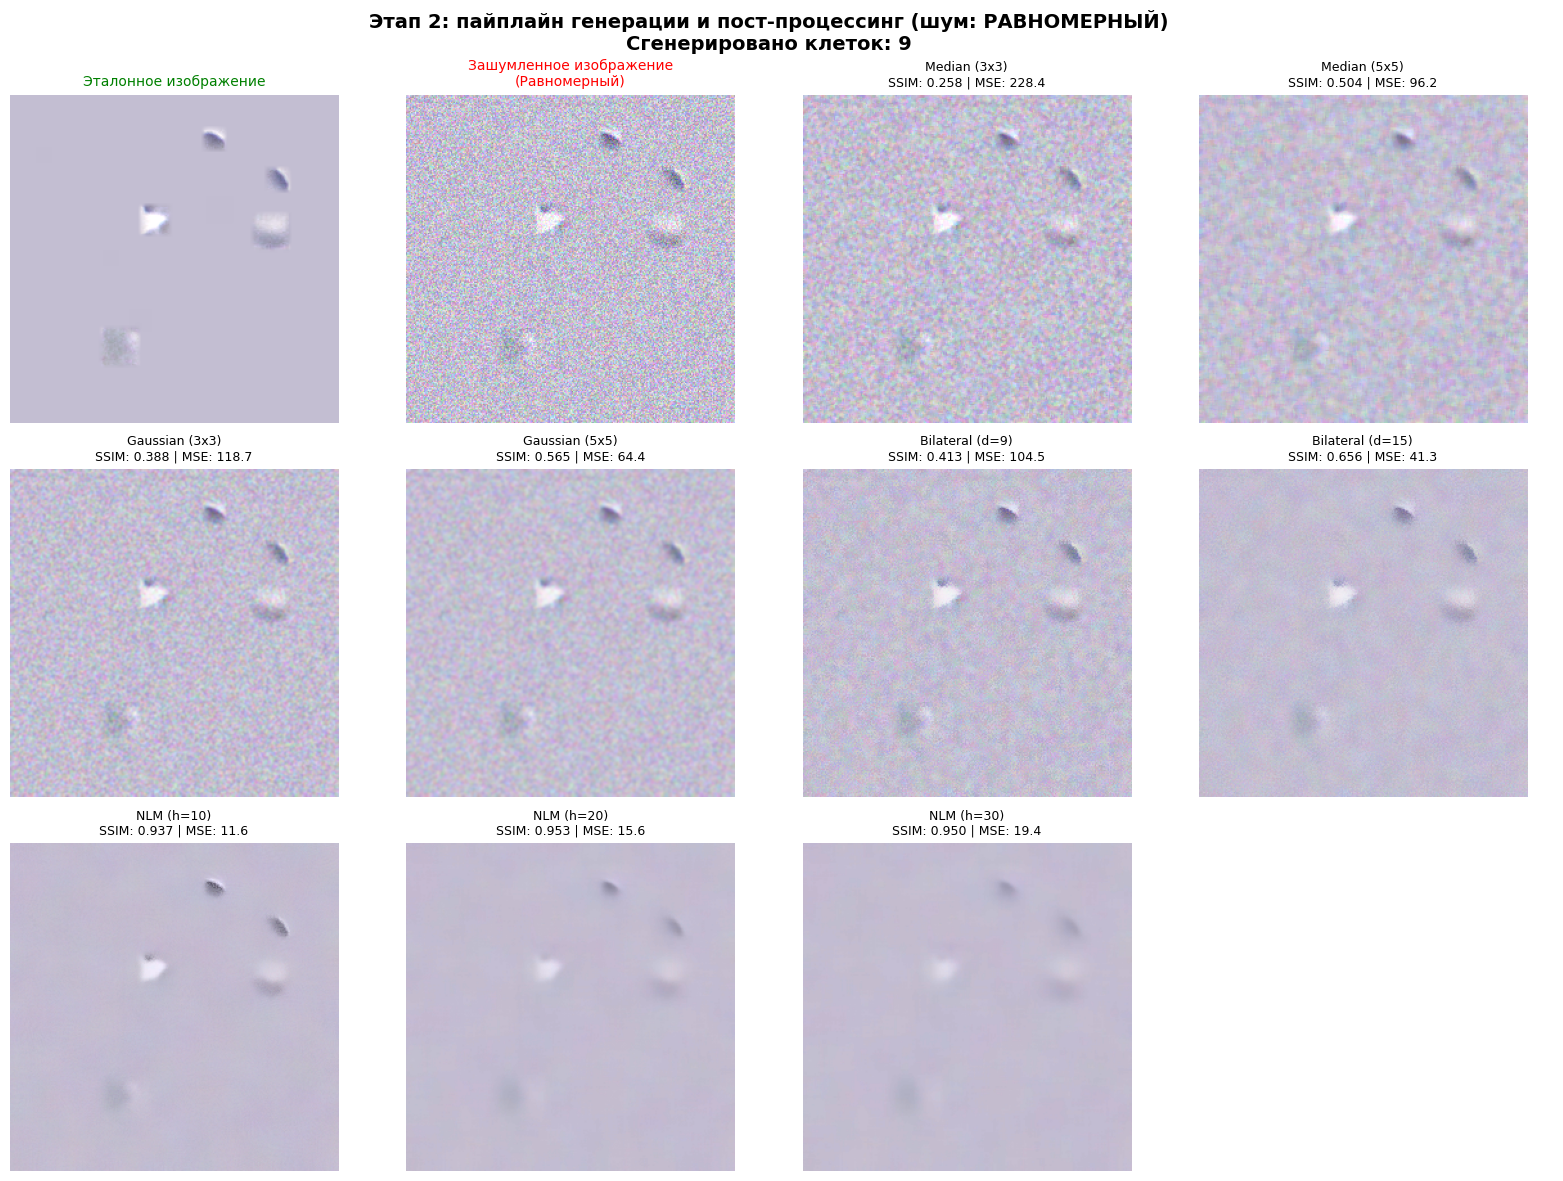

In [11]:
# Пример для Равномерного шума
ds_unif = BloodCellDataset(
    img_size=(256, 256), dataset_size=1, 
    bg_patches=bg_patches_list, cell_patches=cell_patches_list,
    noise_type='uniform', use_synthetic=True
)
visualize_pipeline(ds_unif, filters_dict, "Равномерный")